# Gradient descent

In this notebook we will implement the gradient descent and stochastic gradient descent algorithms.

As usual, use PyTorch tensor operations — no `torch.nn`, no `numpy`.

Work through the cells below and complete the tasks indicated by <span style="color:red">**TODO**</span>.
Most of the code shall be developed within the script `todos.py`.

In [2]:
# magic for autoreloading of modules
%reload_ext autoreload
%autoreload 2

# import libraries
import torch
import numpy as np  # for csv loading and plotting
import helpers as hlp
import todos_complete as td


## Data

First we need to load the data from `data.csv`.
The first column is the inputs $x$, the second is the outputs $y$.

In [3]:
# load data from csv
data_np = np.loadtxt('data.csv', delimiter=",")
data = torch.from_numpy(data_np).float()
print(f'Data shape: {data.shape}')


Data shape: torch.Size([1000, 2])


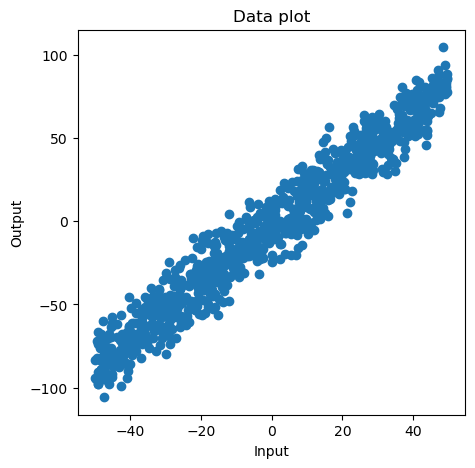

In [4]:
# plot data
hlp.plot_data(data[:,0], data[:,1])

## Closed form solution of a linear regression problem

We will model the data by a simple linear regression model $y = \theta_0 + \theta_1 x$.

The solution for a linear regression problem with MSE loss is easy and available in closed form. 

<span style="color:red">**TODO 1:**</span> Derive the closed form solution on paper using calculus and then implement it in the function `linreg_closed` in the script `todos.py`.


In [5]:
# get linear model parameters
c_theta_0, c_theta_1 = td.linreg_closed(data)

print(f'Our linear model: y = {c_theta_0} + {c_theta_1} x')

Our linear model: y = -2.6369218826293945 + 1.6905831098556519 x


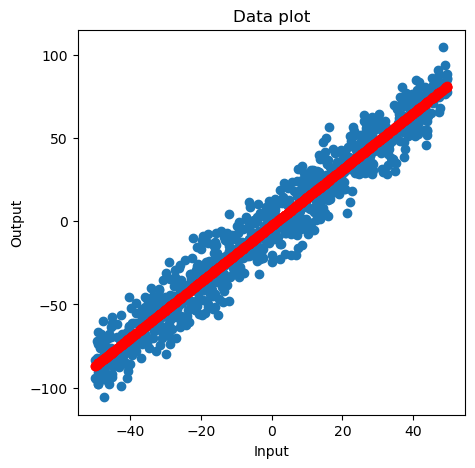

In [6]:
# plot predictions
y_pred_c = c_theta_0 + c_theta_1 * data[:,0]

hlp.plot_data(data[:,0], data[:,1], y_pred_c)

## Mean square error loss

<span style="color:red">**TODO 2:**</span> Implement the function `mse` in the script `todos.py`.

In [7]:
# get the loss
loss_closed = td.mse(data[:,1], y_pred_c)

print(f'MSE loss from closed form solution: {loss_closed}')

MSE loss from closed form solution: 109.49858856201172


## Gradient descent

An alternative to the closed form solution is the gradient descent algorithm. 
For such a simple problem as linear regression we do not really need it, but let's try anyway.

<span style="color:red">**TODO 3:**</span> Implement the function `linreg_gd` in the script `todos.py`.


Our linear model: y = -0.006660843268036842 + 1.3500304222106934 x


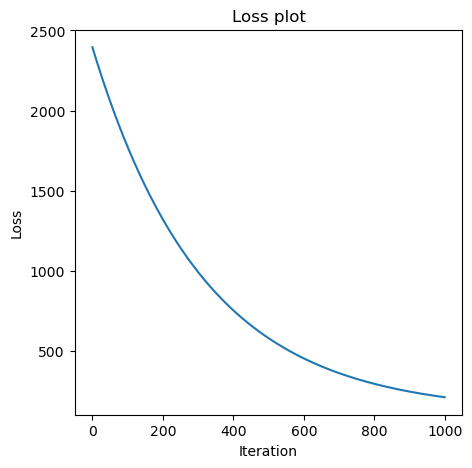

In [8]:
# gradient descent
gd_theta_0, gd_theta_1, gd_losses = td.linreg_gd(data, 0.000001)

print(f'Our linear model: y = {gd_theta_0} + {gd_theta_1} x')

# plot losses
hlp.plot_loss(gd_losses)

In [9]:
# get loss for complete trainset
y_pred_gd = gd_theta_0 + gd_theta_1 * data[:,0]
loss_gd = td.mse(data[:,1], y_pred_gd)

print(f'MSE loss from gradient descent form solution: {loss_gd}')


MSE loss from gradient descent form solution: 210.36660766601562


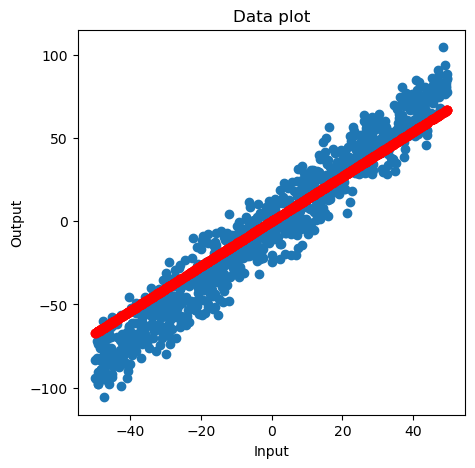

In [10]:
# plot predictions
hlp.plot_data(data[:,0], data[:,1], y_pred_gd)

## Stochastic gradient descent

Finally, let's try the stochastic version of the gradient descent with mini-batches.

<span style="color:red">**TODO 4:**</span> Implement the function `linreg_sgd` in the script `todos.py`. 

Our linear model: y = -0.053891975432634354 + 1.6933609247207642 x


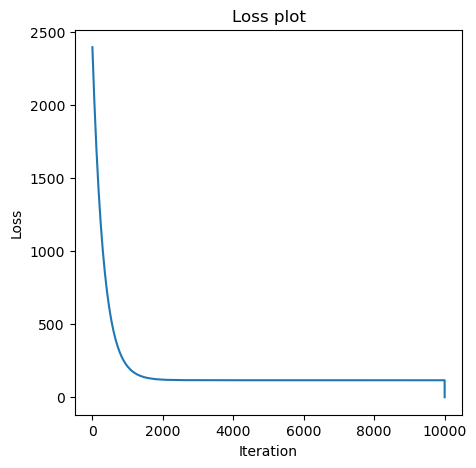

In [19]:
# stochastic gradient descent
sgd_theta_0, sgd_theta_1, sgd_losses = td.linreg_sgd(data, 100, 0.000001)

print(f'Our linear model: y = {sgd_theta_0} + {sgd_theta_1} x')

# plot losses
hlp.plot_loss(sgd_losses)

In [13]:
# get loss for complete trainset
y_pred_sgd = sgd_theta_0 + sgd_theta_1 * data[:,0]
loss_sgd = td.mse(data[:,1], y_pred_sgd)

print(f'MSE loss from gradient descent form solution: {loss_sgd}')

MSE loss from gradient descent form solution: 116.16486358642578


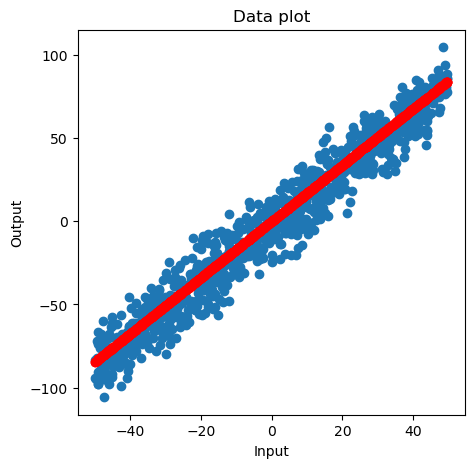

In [14]:
# plot predictions
hlp.plot_data(data[:,0], data[:,1], y_pred_sgd)

This photos for stochastic NN:

<img src='img1.png' width=700 height=300>

<img src='img2.png' height=400 width=700>

<img src='img3.png' height=400 width=600>